# Taller práctico de regresión lineal

## Predicción del precio de viviendas a partir de su tamaño

Universidad El Bosque · Doctorado en Ciencia de Datos e Inteligencia Artificial

En Google Colab: **Entorno de ejecución → Ejecutar todas**. El notebook carga directamente el CSV público y no necesita archivos locales. Al final hay un control interactivo. La URL de apertura directa se añadirá cuando este archivo esté publicado; por ahora use **Archivo → Subir notebook**.

# Introducción y objetivo

Este taller desarrolla una regresión lineal simple para estimar el precio de una
vivienda a partir de su tamaño. Se sigue el enunciado del Taller Práctico de
Regresión Lineal de la Universidad El Bosque: carga y exploración, tratamiento de
faltantes, entrenamiento, evaluación, predicción y visualización. El objetivo es
construir un procedimiento reproducible y comprender sus decisiones estadísticas.

El tamaño se expresa en metros cuadrados (m²) y el precio en pesos colombianos
(COP), según el enunciado. Se mantiene la escala original del CSV: no se supone
que los precios estén expresados en miles o millones ni se ajustan a precios del
mercado. El enunciado describe un conjunto realista; no se dispone de información
para afirmar que representa transacciones inmobiliarias observadas.

# Carga y exploración inicial

## Herramientas y lectura directa

Se importan las herramientas para manipular datos, dividir la muestra, imputar,
entrenar y evaluar. `random_state=42` fija las selecciones aleatorias. Las funciones
de formato solo cambian la presentación; no redondean los datos del modelo.
Google Colab incluye estas bibliotecas. Para una instalación local se proporcionan
las dependencias junto al taller.

In [1]:
import io
import sys
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_squared_error,
    mean_absolute_percentage_error,
)

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 10})
pd.set_option("display.max_columns", 8)

def numero(valor, decimales=2):
    texto = f"{valor:,.{decimales}f}"
    return texto.replace(",", "_").replace(".", ",").replace("_", ".")

def cop(valor):
    return f"{numero(valor, 0)} COP"

url = (
    "https://storage.googleapis.com/"
    "backet_doctorado_ueb_2026_2/datos_viviendas_faltantes.csv"
)
df = pd.read_csv(url)
print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())
assert set(df.columns) == {"tamano", "precio"}
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns)
assert np.isfinite(df.dropna().to_numpy()).all()
print(df.head().to_string(index=False))

Dimensiones: (100000, 2)
Columnas: ['tamano', 'precio']
 tamano   precio
    NaN 532530.0
  143.8 351732.0
  179.1 526522.0
  218.5 565288.0
  139.5 382380.0


In [2]:
n_filas, n_columnas = df.shape
display(Markdown(
    f"Se cargaron **{numero(n_filas, 0)} observaciones y "
    f"{n_columnas} variables**. Los nombres reales son `tamano` y "
    "`precio`; se conserva esa escritura en el código. Las primeras "
    "cinco filas permiten revisar la escala y advertir faltantes, "
    "pero no representan por sí solas la distribución del conjunto."
))

Se cargaron **100.000 observaciones y 2 variables**. Los nombres reales son `tamano` y `precio`; se conserva esa escritura en el código. Las primeras cinco filas permiten revisar la escala y advertir faltantes, pero no representan por sí solas la distribución del conjunto.

## Tipos, información general y faltantes

`info()` resume tipos y recuentos no nulos. Además, se cuentan explícitamente los
faltantes y se divide por el número total de filas para obtener su porcentaje en
cada variable. El porcentaje sobre celdas y el porcentaje de filas afectadas son
medidas distintas y se informan por separado.

In [3]:
buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())
faltantes = pd.DataFrame({
    "Variable": df.columns,
    "Cantidad": df.isnull().sum().to_numpy(),
    "Porcentaje": df.isnull().mean().to_numpy() * 100,
})
print(faltantes.to_string(index=False))
filas_afectadas = int(df.isna().any(axis=1).sum())
pct_celdas = df.isna().to_numpy().mean() * 100

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tamano  90000 non-null  float64
 1   precio  95000 non-null  float64
dtypes: float64(2)
memory usage: 1.5 MB

Variable  Cantidad  Porcentaje
  tamano     10000        10.0
  precio      5000         5.0


In [4]:
display(Markdown(
    f"Ambas variables tienen tipo `{df['tamano'].dtype}`. "
    f"Faltan {numero(df.tamano.isna().sum(), 0)} tamaños "
    f"({numero(df.tamano.isna().mean()*100)} %) y "
    f"{numero(df.precio.isna().sum(), 0)} precios "
    f"({numero(df.precio.isna().mean()*100)} %). "
    f"Hay {numero(filas_afectadas, 0)} filas con al menos un faltante "
    f"({numero(filas_afectadas/n_filas*100)} % de las filas); "
    f"{numero(pct_celdas)} % de todas las celdas están vacías. "
    "Los faltantes pueden coincidir en una misma fila; por eso no "
    "se suman los porcentajes por columna para contar filas afectadas."
))

Ambas variables tienen tipo `float64`. Faltan 10.000 tamaños (10,00 %) y 5.000 precios (5,00 %). Hay 14.499 filas con al menos un faltante (14,50 % de las filas); 7,50 % de todas las celdas están vacías. Los faltantes pueden coincidir en una misma fila; por eso no se suman los porcentajes por columna para contar filas afectadas.

## Estadísticas descriptivas

Se calculan las estadísticas usando los valores observados de cada variable,
antes de imputar. La mediana es el cuartil 50 %. Los cuartiles 25 % y 75 %
delimitan la mitad central de los datos. La desviación estándar muestral resume
la dispersión alrededor de la media, en las unidades originales.

In [5]:
descriptivos = df.describe()
print(descriptivos.to_string(float_format=lambda x: f"{x:.2f}"))
print("Asimetría muestral:")
print(df.skew().round(4).to_string())

        tamano     precio
count 90000.00   95000.00
mean    150.07  425238.13
std      44.91  123138.41
min      30.00   30000.00
25%     119.60  342106.75
50%     150.10  425243.50
75%     180.40  508401.25
max     351.60 1002767.00
Asimetría muestral:
tamano    0.0242
precio    0.0159


In [6]:
for variable, unidad in [("tamano", "m²"), ("precio", "COP")]:
    s = descriptivos[variable]
    display(Markdown(
        f"**{variable}:** media {numero(s['mean'])} {unidad}; "
        f"mediana {numero(s['50%'])} {unidad}; desviación estándar "
        f"{numero(s['std'])} {unidad}. La mitad central está entre "
        f"{numero(s['25%'])} y {numero(s['75%'])} {unidad}, "
        f"y el rango observado va de {numero(s['min'])} a "
        f"{numero(s['max'])} {unidad}. La proximidad entre media "
        f"y mediana, junto con una asimetría de "
        f"{numero(df[variable].skew(), 4)}, es compatible con "
        "una distribución aproximadamente simétrica; no demuestra normalidad."
    ))
display(Markdown(
    "No se eliminan valores extremos: su magnitud aislada no demuestra "
    "que sean errores. Estas estadísticas describen los valores disponibles; "
    "si la ausencia depende del tamaño o del precio, podrían estar sesgadas."
))

**tamano:** media 150,07 m²; mediana 150,10 m²; desviación estándar 44,91 m². La mitad central está entre 119,60 y 180,40 m², y el rango observado va de 30,00 a 351,60 m². La proximidad entre media y mediana, junto con una asimetría de 0,0242, es compatible con una distribución aproximadamente simétrica; no demuestra normalidad.

**precio:** media 425.238,13 COP; mediana 425.243,50 COP; desviación estándar 123.138,41 COP. La mitad central está entre 342.106,75 y 508.401,25 COP, y el rango observado va de 30.000,00 a 1.002.767,00 COP. La proximidad entre media y mediana, junto con una asimetría de 0,0159, es compatible con una distribución aproximadamente simétrica; no demuestra normalidad.

No se eliminan valores extremos: su magnitud aislada no demuestra que sean errores. Estas estadísticas describen los valores disponibles; si la ausencia depende del tamaño o del precio, podrían estar sesgadas.

# Análisis exploratorio de la relación

Se dibujan pares con ambas variables observadas. Para evitar superposición se
selecciona una muestra reproducible de hasta 3.000 pares **solo para visualizar**.
La correlación de Pearson se calcula con todos los pares completos, sin imputar.
Los ejes muestran metros cuadrados y COP, con separadores de miles.

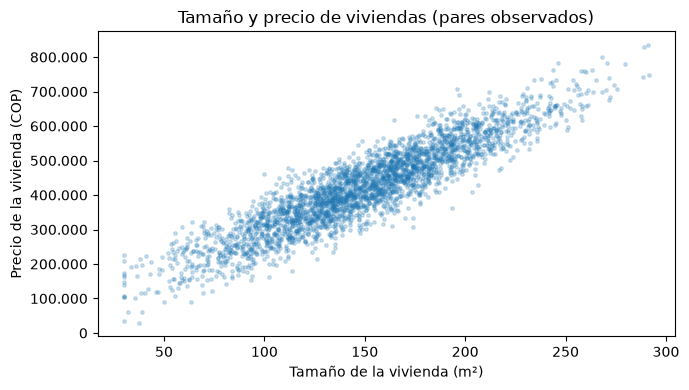

Pares completos: 85501
Correlación de Pearson: 0.9143


In [7]:
from matplotlib.ticker import FuncFormatter

pares = df.dropna(subset=["tamano", "precio"])
muestra = pares.sample(n=min(3000, len(pares)), random_state=SEED)
correlacion = pares.tamano.corr(pares.precio)
formato_cop = FuncFormatter(lambda x, pos: numero(x, 0))
fig, ax = plt.subplots()
ax.scatter(muestra.tamano, muestra.precio, s=6, alpha=0.22)
ax.set(title="Tamaño y precio de viviendas (pares observados)",
       xlabel="Tamaño de la vivienda (m²)",
       ylabel="Precio de la vivienda (COP)")
ax.yaxis.set_major_formatter(formato_cop)
fig.tight_layout()
plt.show()
print("Pares completos:", len(pares))
print("Correlación de Pearson:", round(correlacion, 4))

In [8]:
display(Markdown(
    f"La nube presenta una tendencia creciente aproximadamente lineal. "
    f"La correlación de Pearson es **{numero(correlacion, 4)}**, "
    "coherente con una asociación positiva importante. Existe dispersión "
    "alrededor de esa tendencia: el tamaño no determina por completo el precio. "
    "La correlación no prueba causalidad y se refiere a los pares observados, "
    "no al conjunto de prueba con tamaños imputados."
))

La nube presenta una tendencia creciente aproximadamente lineal. La correlación de Pearson es **0,9143**, coherente con una asociación positiva importante. Existe dispersión alrededor de esa tendencia: el tamaño no determina por completo el precio. La correlación no prueba causalidad y se refiere a los pares observados, no al conjunto de prueba con tamaños imputados.

# Tratamiento de faltantes y preparación del modelo

## Decisión de imputación

Eliminar todas las filas incompletas es sencillo, pero pierde viviendas cuyo
precio sí se conoce. La imputación con **media** conserva esas observaciones y
resulta razonable para tamaños aproximadamente simétricos, con media y mediana
cercanas. La **mediana** sería más resistente a asimetría intensa o extremos
influyentes. Ninguna de las dos recupera el tamaño real ni incorpora la
incertidumbre de la imputación.

Se elige la **media para `tamano`**. Para `precio` se adopta una decisión diferente:
las filas sin objetivo se excluyen del análisis supervisado. Imputar el precio
crearía etiquetas artificiales y haría que parte de la evaluación midiera el
ajuste a valores inventados. El DataFrame original se conserva intacto. Se
construirá un dataset de modelado completo con las filas de precio observado.

La media debe estimarse **después de dividir** y únicamente con entrenamiento.
Así se evita fuga de información (*data leakage*): el conjunto de prueba no
interviene en la preparación aprendida por el modelo. Esta es la razón para
aplicar la imputación después de la separación, aunque se haya justificado antes.

## Variables y división 80/20

`X` se define como un DataFrame de una columna: scikit-learn espera una matriz
bidimensional `(n_observaciones, n_variables)`, incluso con un solo predictor.
`y` es una serie unidimensional de precios. El entrenamiento (*training set*)
sirve para estimar la media y la recta; la prueba (*test set*) queda reservada
para evaluar predicciones sobre observaciones no usadas para ajustar el modelo.
Evaluar solo entrenamiento daría una visión potencialmente optimista.

In [9]:
datos = df.loc[df.precio.notna(), ["tamano", "precio"]].copy()
X = datos[["tamano"]]
y = datos["precio"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print("X:", X.shape, "y:", y.shape)
print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))
assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(datos)

X: (95000, 1) y: (95000,)
Entrenamiento: 76000
Prueba: 19000


In [10]:
display(Markdown(
    f"Se excluyen del modelado {numero(df.precio.isna().sum(), 0)} "
    f"filas sin precio. De las {numero(len(datos), 0)} restantes, "
    f"{numero(len(X_train), 0)} forman entrenamiento (80 %) y "
    f"{numero(len(X_test), 0)} forman prueba (20 %). "
    "La división aleatoria es adecuada para este ejercicio sin variables "
    "temporales ni identificadores de grupos. La ausencia de esos campos "
    "impide comprobar dependencias entre viviendas."
))

Se excluyen del modelado 5.000 filas sin precio. De las 95.000 restantes, 76.000 forman entrenamiento (80 %) y 19.000 forman prueba (20 %). La división aleatoria es adecuada para este ejercicio sin variables temporales ni identificadores de grupos. La ausencia de esos campos impide comprobar dependencias entre viviendas.

## Imputación y validación explícita

`fit_transform` aprende y aplica la media en entrenamiento; `transform` aplica
esa misma media en prueba. Se mantienen los índices para alinear los precios.
Luego se verifica que ambos conjuntos y su unión estén completos. No se borra
ningún archivo ni se modifica el CSV remoto.

In [11]:
imputador = SimpleImputer(strategy="mean")
X_train_imp = pd.DataFrame(
    imputador.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index,
)
X_test_imp = pd.DataFrame(
    imputador.transform(X_test),
    columns=X_test.columns, index=X_test.index,
)
media_entrenamiento = float(imputador.statistics_[0])
df_modelado = pd.concat([X_train_imp, X_test_imp]).join(y)
print("Media de imputación (m²):", round(media_entrenamiento, 4))
print("Faltantes después de imputar:")
print(df_modelado.isnull().sum().to_string())
assert not df_modelado.isnull().any().any()
assert np.isfinite(df_modelado.to_numpy()).all()
assert df_modelado.index.is_unique
print("Dataset de modelado completo:", df_modelado.shape)

Media de imputación (m²): 150.0321
Faltantes después de imputar:
tamano    0
precio    0
Dataset de modelado completo: (95000, 2)


In [12]:
display(Markdown(
    f"La media aprendida es **{numero(media_entrenamiento, 4)} m²**. "
    f"Se imputan {numero(X_train.tamano.isna().sum(), 0)} tamaños en "
    f"entrenamiento y {numero(X_test.tamano.isna().sum(), 0)} en prueba. "
    "La validación confirma cero faltantes en las dos variables del dataset "
    "de modelado. La imputación concentra viviendas en un mismo tamaño y "
    "reduce artificialmente su dispersión; no equivale a observar ese tamaño. "
    "La estrategia no demuestra que los faltantes sean aleatorios."
))

La media aprendida es **150,0321 m²**. Se imputan 7.570 tamaños en entrenamiento y 1.929 en prueba. La validación confirma cero faltantes en las dos variables del dataset de modelado. La imputación concentra viviendas en un mismo tamaño y reduce artificialmente su dispersión; no equivale a observar ese tamaño. La estrategia no demuestra que los faltantes sean aleatorios.

# Construcción de la regresión lineal

El modelo estima una recta por mínimos cuadrados ordinarios: elige intercepto y
pendiente para minimizar la suma de residuos cuadrados de entrenamiento. No se
utilizan los precios de prueba durante el ajuste. La ecuación general es

$$\widehat{\mathrm{precio}} = \hat\beta_0 + \hat\beta_1\,\mathrm{tamano}.$$

In [13]:
modelo = LinearRegression()
modelo.fit(X_train_imp, y_train)
intercepto = float(modelo.intercept_)
coeficiente = float(modelo.coef_[0])
print("Intercepto (COP):", round(intercepto, 4))
print("Coeficiente (COP/m²):", round(coeficiente, 4))
print(f"precio_estimado = {intercepto:.4f} + {coeficiente:.4f} × tamano")

Intercepto (COP): 49539.4539
Coeficiente (COP/m²): 2504.473
precio_estimado = 49539.4539 + 2504.4730 × tamano


In [14]:
display(Markdown(
    "La ecuación estimada, con coeficientes redondeados solo para presentación, es:\n\n"
    f"$$\\widehat{{\\mathrm{{precio}}}} = {intercepto:.4f} "
    f"+ {coeficiente:.4f}\\,\\mathrm{{tamano}}.$$\n\n"
    f"Un metro cuadrado adicional se asocia con **{cop(coeficiente)}** "
    "más de precio estimado, en promedio según esta recta. Es una asociación "
    "predictiva, no un efecto causal. El intercepto "
    f"({cop(intercepto)}) corresponde matemáticamente a cero m², "
    "fuera del rango observado; no debe interpretarse como el precio real "
    "de una vivienda sin área. Las predicciones usan los coeficientes completos."
))

La ecuación estimada, con coeficientes redondeados solo para presentación, es:

$$\widehat{\mathrm{precio}} = 49539.4539 + 2504.4730\,\mathrm{tamano}.$$

Un metro cuadrado adicional se asocia con **2.504 COP** más de precio estimado, en promedio según esta recta. Es una asociación predictiva, no un efecto causal. El intercepto (49.539 COP) corresponde matemáticamente a cero m², fuera del rango observado; no debe interpretarse como el precio real de una vivienda sin área. Las predicciones usan los coeficientes completos.

# Predicciones y evaluación en prueba

## Comparación de precios

Se predicen todos los casos de prueba y se muestran únicamente ocho. Se define
el error o residuo como `precio real − precio predicho`: un valor positivo indica
subestimación y uno negativo, sobreestimación. Se identifica qué tamaños fueron
imputados para no confundirlos con mediciones reales.

In [15]:
y_pred = modelo.predict(X_test_imp)
residuos = y_test.to_numpy() - y_pred
comparacion = pd.DataFrame({
    "m² usado": X_test_imp.tamano.to_numpy(),
    "Imputado": X_test.tamano.isna().to_numpy(),
    "Real COP": y_test.to_numpy(),
    "Predicho COP": y_pred,
    "Error COP": residuos,
})
print(comparacion.head(8).to_string(
    index=False, float_format=lambda x: f"{x:.2f}"
))

 m² usado  Imputado  Real COP  Predicho COP  Error COP
   150.03      True 289013.00     425290.89 -136277.89
   176.30     False 409808.00     491078.04  -81270.04
    52.70     False 116167.00     181525.18  -65358.18
   179.50     False 493226.00     499092.35   -5866.35
    79.50     False 303429.00     248645.05   54783.95
   105.70     False 297813.00     314262.25  -16449.25
   192.30     False 474453.00     531149.61  -56696.61
   150.03      True 517972.00     425290.89   92681.11


In [16]:
display(Markdown(
    f"En los ocho casos mostrados, los errores van de "
    f"{cop(comparacion.head(8)['Error COP'].min())} a "
    f"{cop(comparacion.head(8)['Error COP'].max())}. "
    "Esta muestra ilustra cómo comparar precios, pero no permite juzgar "
    "el rendimiento general; las métricas siguientes usan toda la prueba."
))

En los ocho casos mostrados, los errores van de -136.278 COP a 92.681 COP. Esta muestra ilustra cómo comparar precios, pero no permite juzgar el rendimiento general; las métricas siguientes usan toda la prueba.

## R², RMSE y MAPE

Se calculan tres métricas complementarias sobre precios observados. $R^2$ compara
el error cuadrático con la variación de los precios alrededor de su media en
prueba; puede ser negativo si el modelo resulta peor que esa referencia.
El RMSE penaliza más los errores grandes y mantiene las unidades COP.
El MAPE promedia los errores absolutos relativos a cada precio real, por lo que
puede dar mucho peso a precios bajos. Se verifica que no existan precios cero o
negativos antes de interpretarlo como porcentaje.

$$R^2 = 1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2},\qquad
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_i(y_i-\hat y_i)^2}.$$

$$\mathrm{MAPE}(\%)=\frac{100}{n}\sum_i
\left|\frac{y_i-\hat y_i}{y_i}\right|.$$

In [17]:
assert (y_test > 0).all(), "MAPE requiere revisar precios no positivos"
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
pred_base = np.full(len(y_test), y_train.mean())
rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
print(f"R²: {r2:.6f}")
print(f"Variabilidad explicada: {r2*100:.2f} %")
print(f"RMSE: {cop(rmse)}")
print(f"MAPE: {numero(mape)} %")
print(f"RMSE referencia (media de entrenamiento): {cop(rmse_base)}")
assert np.isfinite([r2, rmse, mape]).all()

R²: 0.753080
Variabilidad explicada: 75.31 %
RMSE: 60.813 COP
MAPE: 12,42 %
RMSE referencia (media de entrenamiento): 122.382 COP


In [18]:
display(Markdown(
    f"**R² = {numero(r2, 4)}:** el modelo explica aproximadamente "
    f"**{numero(r2*100)} %** de la variabilidad de los precios en prueba "
    "respecto de su media. Esto no significa que ese porcentaje de "
    "predicciones sea correcto.\n\n"
    f"**RMSE = {cop(rmse)}:** la raíz del promedio de errores cuadrados "
    "resume la magnitud del error en pesos y penaliza especialmente "
    "las desviaciones grandes. No es un límite máximo ni un intervalo "
    "de confianza. La referencia que siempre predice la media de "
    f"entrenamiento tiene RMSE de {cop(rmse_base)}; la recta reduce "
    f"ese error en {numero((1-rmse/rmse_base)*100)} %.\n\n"
    f"**MAPE = {numero(mape)} %:** el error absoluto relativo promedio "
    f"es aproximadamente {numero(mape)} % del precio real. Describe "
    "un promedio, no la mediana ni una garantía para cada vivienda. "
    "No debe convertirse en una supuesta exactitud de 100 menos MAPE."
))

**R² = 0,7531:** el modelo explica aproximadamente **75,31 %** de la variabilidad de los precios en prueba respecto de su media. Esto no significa que ese porcentaje de predicciones sea correcto.

**RMSE = 60.813 COP:** la raíz del promedio de errores cuadrados resume la magnitud del error en pesos y penaliza especialmente las desviaciones grandes. No es un límite máximo ni un intervalo de confianza. La referencia que siempre predice la media de entrenamiento tiene RMSE de 122.382 COP; la recta reduce ese error en 50,31 %.

**MAPE = 12,42 %:** el error absoluto relativo promedio es aproximadamente 12,42 % del precio real. Describe un promedio, no la mediana ni una garantía para cada vivienda. No debe convertirse en una supuesta exactitud de 100 menos MAPE.

## Efecto de los tamaños faltantes en la evaluación

La evaluación principal incluye todas las filas de prueba con precio conocido,
como ocurriría al predecir con tamaños disponibles o imputados. Como diagnóstico,
se separa el error entre ambos grupos sin volver a entrenar ni seleccionar otro
modelo a partir de prueba. Esto permite explicar parte de la pérdida de precisión.

In [19]:
imputado_test = X_test.tamano.isna().to_numpy()
filas_metricas = []
for nombre, mascara in [
    ("Observado", ~imputado_test), ("Imputado", imputado_test)
]:
    filas_metricas.append({
        "Tamaño": nombre, "n": int(mascara.sum()),
        "RMSE COP": np.sqrt(mean_squared_error(
            y_test.to_numpy()[mascara], y_pred[mascara])),
        "MAPE %": mean_absolute_percentage_error(
            y_test.to_numpy()[mascara], y_pred[mascara]) * 100,
    })
metricas_grupo = pd.DataFrame(filas_metricas)
print(metricas_grupo.to_string(index=False, float_format="%.2f"))

   Tamaño     n  RMSE COP  MAPE %
Observado 17071  49830.24   10.67
 Imputado  1929 120216.26   27.94


In [20]:
display(Markdown(
    f"El RMSE es {cop(metricas_grupo.iloc[0]['RMSE COP'])} con "
    f"tamaño observado y {cop(metricas_grupo.iloc[1]['RMSE COP'])} "
    "con tamaño imputado. En el segundo grupo todas las viviendas "
    "reciben el mismo tamaño y, por tanto, el mismo precio estimado: "
    "se pierde la información que permitiría distinguirlas. Las métricas "
    "principales mantienen ambos grupos y no ocultan esta limitación."
))

El RMSE es 49.830 COP con tamaño observado y 120.216 COP con tamaño imputado. En el segundo grupo todas las viviendas reciben el mismo tamaño y, por tanto, el mismo precio estimado: se pierde la información que permitiría distinguirlas. Las métricas principales mantienen ambos grupos y no ocultan esta limitación.

# Predicción de una vivienda de 150 m²

Se crea una entrada de una fila y una columna con el mismo nombre usado al
entrenar. La función reutiliza el imputador y el modelo aprendidos. No vuelve a
ajustarlos ni modifica la muestra. Se valida que el tamaño introducido sea finito
y positivo. El ejemplo estático corresponde al control interactivo del notebook.

In [21]:
def predecir_vivienda(tamano):
    if not np.isfinite(tamano) or tamano <= 0:
        raise ValueError("El tamaño debe ser positivo y finito")
    entrada = pd.DataFrame({"tamano": [float(tamano)]})
    entrada_imp = pd.DataFrame(
        imputador.transform(entrada), columns=["tamano"]
    )
    return float(modelo.predict(entrada_imp)[0])

prediccion_150 = predecir_vivienda(150)
print(f"Vivienda de 150 m² → Precio estimado: ${cop(prediccion_150)}")
assert np.isclose(prediccion_150, intercepto + coeficiente * 150)

Vivienda de 150 m² → Precio estimado: $425.210 COP


In [22]:
display(Markdown(
    f"Para **150 m²**, el precio estimado es **{cop(prediccion_150)}**. "
    f"Este tamaño está dentro del rango observado de "
    f"{numero(pares.tamano.min(), 1)} a "
    f"{numero(pares.tamano.max(), 1)} m². Es una estimación puntual "
    "de la recta y no una tasación ni un intervalo predictivo. "
    "La versión Colab incorpora un control de tamaño que actualiza "
    "esta predicción; en PDF se conserva el ejemplo estático."
))

Para **150 m²**, el precio estimado es **425.210 COP**. Este tamaño está dentro del rango observado de 30,0 a 351,6 m². Es una estimación puntual de la recta y no una tasación ni un intervalo predictivo. La versión Colab incorpora un control de tamaño que actualiza esta predicción; en PDF se conserva el ejemplo estático.

# Visualización del ajuste y diagnóstico de residuos

## Observaciones y recta estimada

Se superpone la recta entrenada sobre la misma muestra de pares reales utilizada
en la exploración. La cuadrícula ordenada solo sirve para dibujar la recta.
El modelo se entrenó con todas las filas de entrenamiento, no con esta muestra.
La figura es descriptiva; la evaluación independiente es la del conjunto de prueba.

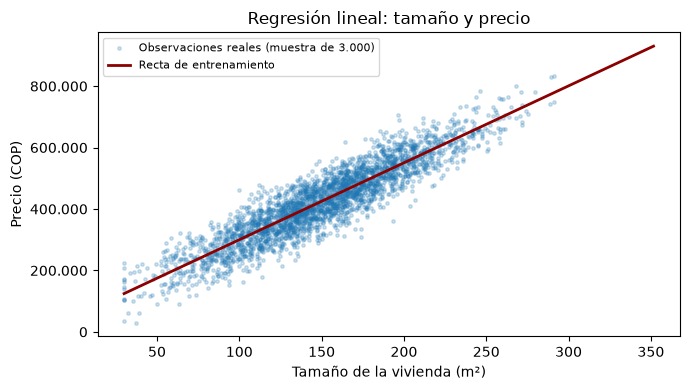

In [23]:
rejilla = pd.DataFrame({
    "tamano": np.linspace(pares.tamano.min(), pares.tamano.max(), 200)
})
fig, ax = plt.subplots()
ax.scatter(muestra.tamano, muestra.precio, s=6, alpha=0.22,
           label="Observaciones reales (muestra de 3.000)")
ax.plot(rejilla.tamano, modelo.predict(rejilla),
        color="darkred", linewidth=2, label="Recta de entrenamiento")
ax.set(title="Regresión lineal: tamaño y precio",
       xlabel="Tamaño de la vivienda (m²)", ylabel="Precio (COP)")
ax.yaxis.set_major_formatter(formato_cop)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

La recta sigue la dirección general de la nube. La dispersión vertical muestra
que viviendas de tamaño similar pueden tener precios distintos, incluso antes
de considerar el efecto de los tamaños imputados.

## Residuos en prueba

Se espera una nube sin curvatura clara, centrada alrededor de cero y con dispersión
aproximadamente estable. Una curva sugeriría una relación mal especificada; un
abanico sugeriría varianza no constante (*heterocedasticidad*). La figura distingue
tamaños imputados de observados y usa hasta 3.000 casos solo para visualización.
Los resúmenes siguientes se calculan con todos los residuos de prueba.

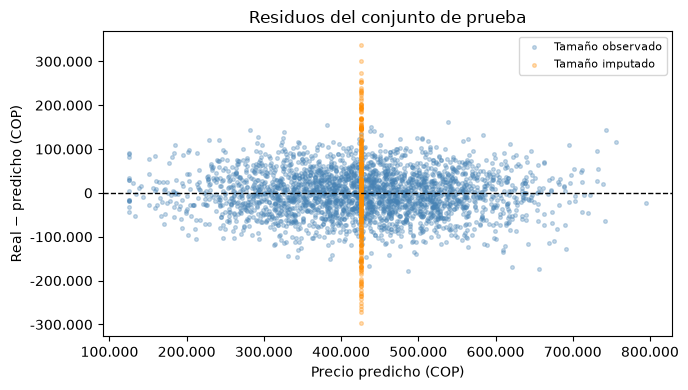

Residuo medio (COP): -389.08
Desviación estándar de residuos (COP): 60813.27


In [24]:
diagnostico = pd.DataFrame({
    "Predicho": y_pred, "Residuo": residuos,
    "Imputado": imputado_test,
})
muestra_res = diagnostico.sample(
    n=min(3000, len(diagnostico)), random_state=SEED
)
fig, ax = plt.subplots()
for valor, color, etiqueta in [
    (False, "steelblue", "Tamaño observado"),
    (True, "darkorange", "Tamaño imputado"),
]:
    grupo = muestra_res[muestra_res.Imputado == valor]
    ax.scatter(grupo.Predicho, grupo.Residuo, s=7, alpha=0.3,
               color=color, label=etiqueta)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(title="Residuos del conjunto de prueba",
       xlabel="Precio predicho (COP)", ylabel="Real − predicho (COP)")
ax.xaxis.set_major_formatter(formato_cop)
ax.yaxis.set_major_formatter(formato_cop)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("Residuo medio (COP):", round(residuos.mean(), 2))
print("Desviación estándar de residuos (COP):", round(residuos.std(ddof=1), 2))

In [25]:
display(Markdown(
    f"El residuo medio es **{cop(residuos.mean())}** y su "
    f"desviación estándar es **{cop(residuos.std(ddof=1))}**. "
    "Un promedio pequeño respecto al RMSE indica poco desplazamiento "
    "global, pero puede ocultar errores opuestos. La banda vertical "
    "de tamaños imputados aparece porque comparten predicción aunque "
    "sus precios reales varían. En los tamaños observados no se aprecia "
    "una curvatura dominante. La inspección visual no prueba normalidad, "
    "independencia ni homocedasticidad; especialmente en los extremos "
    "hay menos datos para juzgar el comportamiento."
))

El residuo medio es **-389 COP** y su desviación estándar es **60.813 COP**. Un promedio pequeño respecto al RMSE indica poco desplazamiento global, pero puede ocultar errores opuestos. La banda vertical de tamaños imputados aparece porque comparten predicción aunque sus precios reales varían. En los tamaños observados no se aprecia una curvatura dominante. La inspección visual no prueba normalidad, independencia ni homocedasticidad; especialmente en los extremos hay menos datos para juzgar el comportamiento.

# Conclusiones

In [26]:
display(Markdown(
    f"1. Existe una asociación lineal positiva importante entre tamaño "
    f"y precio: la correlación en pares observados es "
    f"{numero(correlacion, 4)} y la pendiente estimada es "
    f"{cop(coeficiente)} por m².\n"
    f"2. En prueba, el modelo explica aproximadamente "
    f"{numero(r2*100)} % de la variabilidad del precio "
    f"(R² = {numero(r2, 4)}). La relación es útil, pero incompleta.\n"
    f"3. El RMSE de {cop(rmse)} expresa la escala del error "
    f"cuadrático en pesos; el MAPE de {numero(mape)} % expresa "
    "el error absoluto porcentual promedio. Son medidas distintas "
    "y ninguna garantiza el error de una vivienda particular.\n"
    f"4. Para 150 m² se estiman {cop(prediccion_150)}. Los importes "
    "conservan las unidades declaradas en el enunciado y la escala "
    "del archivo, sin reinterpretarlos como precios de mercado.\n"
    "5. La regresión lineal es una base razonable para este ejercicio: "
    "la tendencia es aproximadamente recta y supera la referencia "
    "constante. Los tamaños imputados tienen menos información "
    "predictiva y requieren cautela.\n"
    "6. Usar únicamente tamaño omite ubicación, estado, antigüedad, "
    "acabados y otras variables que podrían explicar diferencias "
    "de precio; este CSV no permite cuantificar sus efectos. "
    "Tampoco se conoce el mecanismo de ausencia ni el proceso de "
    "muestreo. Excluir precios faltantes puede introducir sesgo de "
    "selección. No se infiere causalidad ni validez fuera de la "
    "población representada. Como extensión, convendría obtener "
    "más predictores, validar externamente y estudiar incertidumbre "
    "de imputación y predicción."
))

1. Existe una asociación lineal positiva importante entre tamaño y precio: la correlación en pares observados es 0,9143 y la pendiente estimada es 2.504 COP por m².
2. En prueba, el modelo explica aproximadamente 75,31 % de la variabilidad del precio (R² = 0,7531). La relación es útil, pero incompleta.
3. El RMSE de 60.813 COP expresa la escala del error cuadrático en pesos; el MAPE de 12,42 % expresa el error absoluto porcentual promedio. Son medidas distintas y ninguna garantiza el error de una vivienda particular.
4. Para 150 m² se estiman 425.210 COP. Los importes conservan las unidades declaradas en el enunciado y la escala del archivo, sin reinterpretarlos como precios de mercado.
5. La regresión lineal es una base razonable para este ejercicio: la tendencia es aproximadamente recta y supera la referencia constante. Los tamaños imputados tienen menos información predictiva y requieren cautela.
6. Usar únicamente tamaño omite ubicación, estado, antigüedad, acabados y otras variables que podrían explicar diferencias de precio; este CSV no permite cuantificar sus efectos. Tampoco se conoce el mecanismo de ausencia ni el proceso de muestreo. Excluir precios faltantes puede introducir sesgo de selección. No se infiere causalidad ni validez fuera de la población representada. Como extensión, convendría obtener más predictores, validar externamente y estudiar incertidumbre de imputación y predicción.

# Reproducibilidad

El análisis se ejecuta desde la URL pública en cada sesión, sin almacenar el CSV
en el repositorio. Se deja una huella del DataFrame y las versiones del entorno
para detectar posibles cambios de datos o bibliotecas. La partición y las muestras
visuales emplean la semilla 42. El notebook incluye todos los pasos y puede
cargarse en Colab mediante **Archivo → Subir notebook**, seguido de
**Entorno de ejecución → Ejecutar todas**.

In [27]:
huella = hashlib.sha256(
    pd.util.hash_pandas_object(df, index=True).values.tobytes()
).hexdigest()
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("SHA-256 del DataFrame (hash dependiente de pandas):")
print(huella)

Python: 3.14.4
pandas: 3.0.5
NumPy: 2.5.3
scikit-learn: 1.9.0
SHA-256 del DataFrame (hash dependiente de pandas):
7c81e7bd8a34c6347a24aa3e564eee539048d5fa1e6af7cfe3d3580bba1ad751


# Predicción interactiva en Colab

El control reutiliza el modelo entrenado. Cambie el tamaño y el resultado se actualizará al soltar el deslizador. Se limita al rango observado de entrenamiento para evitar extrapolaciones evidentes. No se requiere `input()`, de modo que **Ejecutar todas** no queda esperando una respuesta. El control muestra inicialmente el ejemplo de 150 m². El PDF conserva una representación estática de esa predicción.

In [28]:
import ipywidgets as widgets

try:
    from google.colab import output
except ImportError:
    pass  # En Jupyter local no se necesita la integración de Colab.
else:
    output.enable_custom_widget_manager()

control = widgets.FloatSlider(
    value=150.0, min=float(X_train.tamano.min()),
    max=float(X_train.tamano.max()), step=0.1,
    description="Tamaño (m²):", continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="90%"),
)
salida = widgets.HTML()

def actualizar_prediccion(change=None):
    estimado = predecir_vivienda(control.value)
    salida.value = (
        f"<p>Vivienda de {numero(control.value, 1)} m² "
        f"→ Precio estimado: <strong>${cop(estimado)}</strong></p>"
    )

control.observe(actualizar_prediccion, names="value")
display(widgets.VBox([control, salida]))
actualizar_prediccion()


La cifra cambia al variar el tamaño según la pendiente estimada. El control permite explorar la recta; no incorpora nuevas variables ni proporciona intervalos predictivos. La ejecución estática mantiene los resultados y gráficos del taller aunque el visor no soporte widgets.